In [96]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras

In [98]:
training_set=tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
)

Found 825 files belonging to 3 classes.


In [100]:
validation_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=1,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
)

Found 365 files belonging to 3 classes.


In [102]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen= ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest')
validation_datagen= ImageDataGenerator(rescale=1.0/2550)

Explained variance ratio of the first 50 components: [0.25287718 0.165187   0.0716652  0.03588542 0.03315554 0.02600623
 0.02430328 0.01965379 0.01773196 0.01502204 0.01410447 0.01231428
 0.01179722 0.01052803 0.00944708 0.00915785 0.00883845 0.00815304
 0.00778229 0.00727327 0.00661144 0.00611177 0.00578559 0.0056785
 0.00542375 0.00503155 0.00481921 0.00459335 0.00425794 0.00395144
 0.00388271 0.00373022 0.00349437 0.00342655 0.00331294 0.00302678
 0.00295688 0.00284337 0.00279599 0.00265978 0.00259215 0.00255027
 0.00242304 0.00234051 0.00231289 0.00227129 0.00217357 0.00214968
 0.00201989 0.00200402]


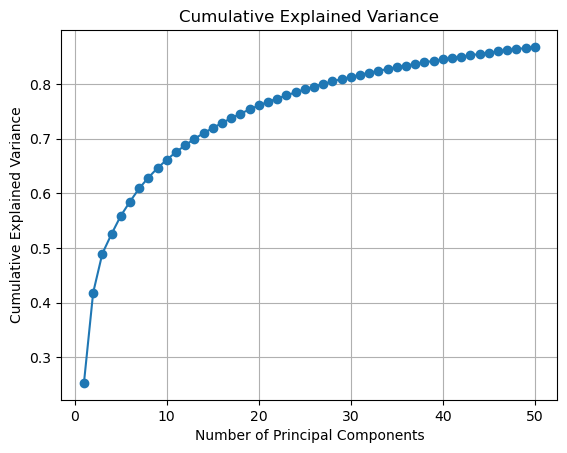

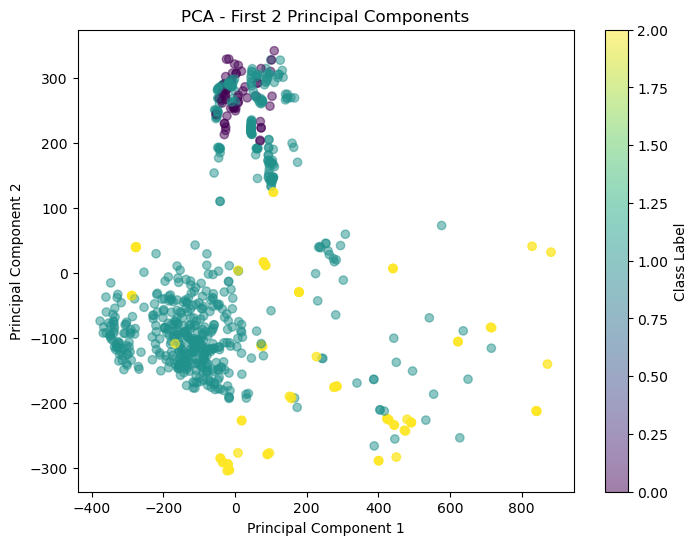

In [104]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

image_data = []
labels = []
for images, batch_labels in training_set:
    # Reshape each image into a 1D vector
    image_data.append(images.numpy().reshape(images.shape[0], -1))  # Flatten images
    labels.append(batch_labels.numpy())  # Store the labels

image_data = np.concatenate(image_data, axis=0)
labels = np.concatenate(labels, axis=0)
scaler = StandardScaler()
image_data_scaled = scaler.fit_transform(image_data)

# Apply PCA
n_components = 50  # You can adjust the number of components as needed
pca = PCA(n_components=n_components)
image_data_pca = pca.fit_transform(image_data_scaled)

# Explained variance ratio
print(f"Explained variance ratio of the first {n_components} components: {pca.explained_variance_ratio_}")

#  cumulative variance explained by the components
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, n_components+1), cumulative_variance, marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

## Visualizing the first 2 principal components in a scatter plot
pca_2d = PCA(n_components=2)
image_data_pca_2d = pca_2d.fit_transform(image_data_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(image_data_pca_2d[:, 0], image_data_pca_2d[:, 1], 
            c=np.argmax(labels, axis=1), cmap='viridis', alpha=0.5)

plt.title('PCA - First 2 Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Class Label')
plt.show()

Explained variance ratio of the first 50 components: [0.20977728 0.13655388 0.07901181 0.05058326 0.04704873 0.03971415
 0.03463234 0.02797577 0.02550647 0.02166799 0.02055513 0.01662263
 0.01562981 0.01378399 0.0125746  0.01113622 0.00986852 0.00854921
 0.00775169 0.00743908 0.0067889  0.00657149 0.00630215 0.00588819
 0.00521987 0.00516759 0.00469684 0.00457889 0.00436324 0.00427399
 0.00400527 0.00372277 0.00357777 0.0033658  0.00332308 0.00314312
 0.0031148  0.00295812 0.00295454 0.00282996 0.00260191 0.00250231
 0.0024948  0.00234752 0.0022544  0.00219029 0.00215626 0.00210925
 0.00204111 0.00193442]


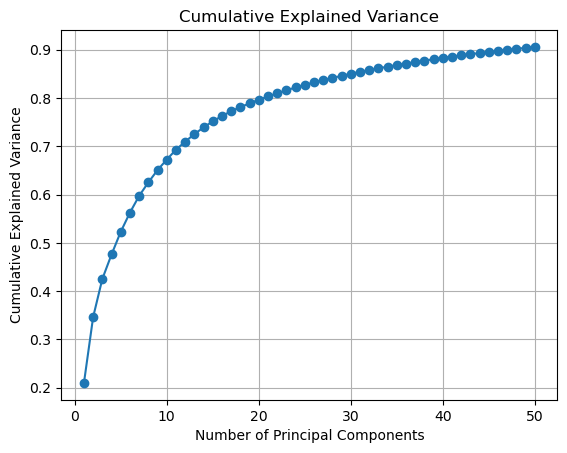

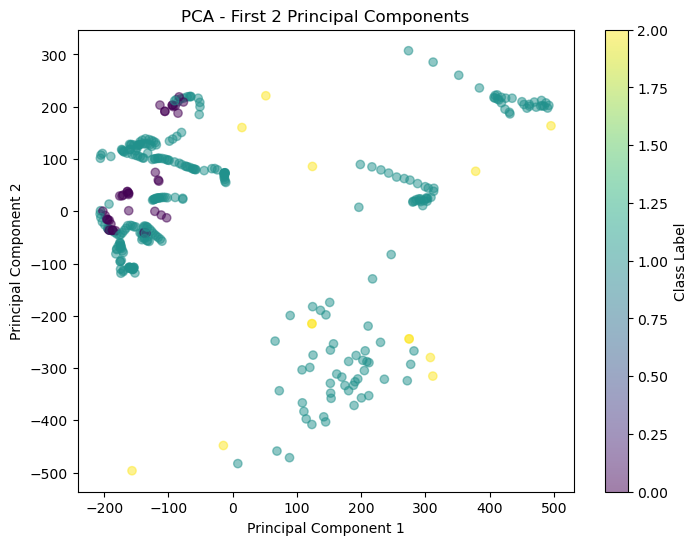

In [105]:
image_data = []
labels = []
for images, batch_labels in validation_set:
    # Reshape each image into a 1D vector
    image_data.append(images.numpy().reshape(images.shape[0], -1))  # Flatten images
    labels.append(batch_labels.numpy())  # Store the labels

image_data = np.concatenate(image_data, axis=0)
labels = np.concatenate(labels, axis=0)
scaler = StandardScaler()
image_data_scaled = scaler.fit_transform(image_data)

# Apply PCA
n_components = 50  # You can adjust the number of components as needed
pca = PCA(n_components=n_components)
image_data_pca = pca.fit_transform(image_data_scaled)

# Explained variance ratio
print(f"Explained variance ratio of the first {n_components} components: {pca.explained_variance_ratio_}")

#  cumulative variance explained by the components
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, n_components+1), cumulative_variance, marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# # Visualizing the first 2 principal components in a scatter plot
pca_2d = PCA(n_components=2)
image_data_pca_2d = pca_2d.fit_transform(image_data_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(image_data_pca_2d[:, 0], image_data_pca_2d[:, 1], 
            c=np.argmax(labels, axis=1), cmap='viridis', alpha=0.5)

plt.title('PCA - First 2 Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Class Label')
plt.show()

In [106]:
training_set, validation_set

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>)

In [107]:
for x,y in training_set:
   print(x,x.shape)
   print(x,y.shape)
   break

tf.Tensor(
[[[[3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   ...
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]]

  [[3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   ...
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]]

  [[3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   ...
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]]

  ...

  [[3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+01 3.8000000e+01 3.8000000e+01]
   [3.8000000e+

In [108]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout,Input
from tensorflow.keras.models import Sequential

In [109]:
model = Sequential()

In [110]:
model.add(Input(shape=[256,256,3]))

In [111]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu',))
model.add(MaxPool2D(pool_size=2,strides=2))

In [112]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu',))
model.add(MaxPool2D(pool_size=2,strides=2))

In [113]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu',))
model.add(MaxPool2D(pool_size=2,strides=2))

In [114]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu',))
model.add(MaxPool2D(pool_size=2,strides=2))

In [115]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu',))
model.add(MaxPool2D(pool_size=2,strides=2))

In [116]:
model.add(Dropout(0.25))

In [117]:
model.add(Flatten())

In [118]:
model.add(Dense(units=1000,activation='relu'))

In [119]:
model.add(Dense(units=3,activation='softmax'))

In [120]:
model.add(Dropout(0.2))

In [121]:
model.compile(optimizer= tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [122]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 254, 254, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 127, 127, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 125, 125, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 62, 62, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │    18,433,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         3,003 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,148,227 (88.30 MB)

 Trainable params: 23,148,227 (88.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor= 'val_loss', patience=10)
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10,callbacks=[early_stopping])

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 191s 7s/step - accuracy: 0.5342 - loss: nan - val_accuracy: 0.8411 - val_loss: 0.7183
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 169s 7s/step - accuracy: 0.6067 - loss: nan - val_accuracy: 0.8575 - val_loss: 0.5609
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 172s 7s/step - accuracy: 0.6622 - loss: nan - val_accuracy: 0.7507 - val_loss: 0.5292
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 175s 7s/step - accuracy: 0.7437 - loss: nan - val_accuracy: 0.8356 - val_loss: 0.3572
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 173s 7s/step - accuracy: 0.7552 - loss: nan - val_accuracy: 0.7534 - val_loss: 0.5064
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7388 - loss: nan

In [ ]:
train_loss,train_acc= model.evaluate(training_set)

In [60]:
val_loss,val_accuracy= model.evaluate(validation_set)

12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.8062 - loss: 0.4114


In [61]:
model.save('3class.keras')

In [64]:
training_history.history

{'accuracy': [0.5903030037879944,
  0.7260606288909912,
  0.803636372089386,
  0.8290908932685852,
  0.8799999952316284,
  0.9042423963546753,
  0.8969696760177612,
  0.8545454740524292,
  0.8824242353439331,
  0.8872727155685425],
 'loss': [nan,
  nan,
  1.7413653135299683,
  nan,
  nan,
  1.440544605255127,
  nan,
  nan,
  nan,
  nan],
 'val_accuracy': [0.8410958647727966,
  0.8575342297554016,
  0.7863013744354248,
  0.7698630094528198,
  0.8328767418861389,
  0.8164383769035339,
  0.6712328791618347,
  0.7424657344818115,
  0.8246575593948364,
  0.8136986494064331],
 'val_loss': [0.5938394069671631,
  0.41831067204475403,
  0.41403698921203613,
  0.44240903854370117,
  0.39862319827079773,
  0.3676358461380005,
  1.0327646732330322,
  0.4844833016395569,
  0.4383821189403534,
  0.43050017952919006]}

In [66]:
import json
with open("training_hist.json","w")as f:
    json.dump(training_history.history,f)

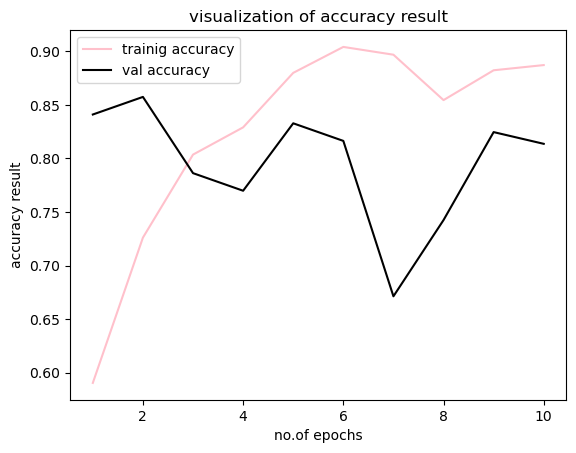

In [68]:
epochs= [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='pink',label='trainig accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='black',label='val accuracy')
plt.xlabel('no.of epochs')
plt.ylabel('accuracy result')
plt.title('visualization of accuracy result')
plt.legend()
plt.show()

In [70]:
class_name= validation_set.class_names
class_name

['benign valid', 'malignant valid', 'normal']

In [72]:
test_set= tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    batch_size=32,
    image_size=(256, 256),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
)

Found 365 files belonging to 3 classes.


In [74]:
Y_pred= model.predict(test_set)
Y_pred,Y_pred.shape

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step


(array([[1.4341350e-01, 8.5658246e-01, 3.9850147e-06],
        [2.4253594e-02, 9.7552437e-01, 2.2203030e-04],
        [1.8184414e-02, 9.8164558e-01, 1.7000599e-04],
        ...,
        [1.2207104e-04, 3.4223959e-01, 6.5763837e-01],
        [1.2207104e-04, 3.4223959e-01, 6.5763837e-01],
        [4.8937809e-09, 9.3531905e-04, 9.9906474e-01]], dtype=float32),
 (365, 3))

In [75]:
Predicted_categories= tf.argmax(Y_pred,axis=1)
Predicted_categories

<tf.Tensor: shape=(365,), dtype=int64, numpy=
array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
     

In [78]:
true_categories= tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(365, 3), dtype=float32, numpy=
array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)>

In [80]:
Y_true= tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(365,), dtype=int64, numpy=
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
     

In [82]:
from sklearn.metrics import classification_report,confusion_matrix

In [84]:
print(classification_report(Y_true,Predicted_categories,target_names=class_name))

                 precision    recall  f1-score   support

   benign valid       0.20      0.07      0.10        45
malignant valid       0.86      0.93      0.89       307
         normal       0.47      0.54      0.50        13

       accuracy                           0.81       365
      macro avg       0.51      0.51      0.50       365
   weighted avg       0.76      0.81      0.78       365



In [86]:
cm= confusion_matrix(Y_true,Predicted_categories)
cm.shape


(3, 3)

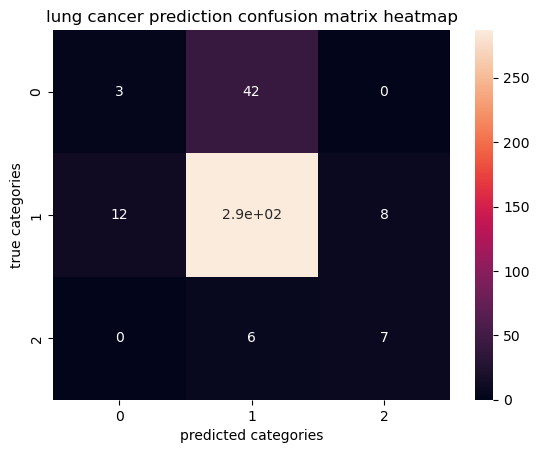

In [88]:
sns.heatmap(cm,annot=True)
plt.ylabel('true categories')
plt.xlabel('predicted categories')
plt.title('lung cancer prediction confusion matrix heatmap')
plt.show()